## Findings — USAID Dataset

- 10,324 rows, 33 columns
- Target (Freight Cost USD): object dtype. 6,198 numeric rows usable (~60%).
  Non-numeric values: 'Freight Included in Commodity Cost' (1,442), 
  reference strings (2,445), 'Invoiced Separately' (239).
- Date range: May 2006 – Aug 2015. Time-based split feasible.
- Shipment mode: TBC. Likely Air-dominant from sample inspection.
- [Fill rest after plots]
- Target log1p distribution: bimodal — two cost populations likely 
  corresponding to Air vs surface modes. Mode = critical feature.
- Weight vs Cost: strong log-log linear relationship confirmed.
- Weight outliers: max 857,354 kg — needs investigation. 23 nulls.
- Air Charter median cost 2-3x Air despite fewer shipments.
- ⚠️ Weight outliers: 5 rows exceed 100,000 kg shipped by Air — 
physically impossible. Likely unit weight × quantity error or 
data entry issue. Will cap/investigate in feature engineering week.
Rows affected: <0.1% of dataset. Strategy: cap at 99th percentile 
or drop in cleaning phase.
- Weight column = total commodity weight (unit weight × quantity), 
  NOT shipment weight. 5 rows >100k kg physically impossible for Air.
  99th pct = 32,769 kg. Will cap at 99th pct in feature engineering.
  Zero weight: 1 row (drop).
- Derived feature candidate: weight_per_unit = Weight / Line Item Quantity
**Target:** 6,198 usable rows. Right-skewed → log1p transform confirmed.
Bimodal log distribution = two cost populations (Air vs surface modes).

**Features:**
- Weight vs freight: nonlinear (power law). Linear corr=0.23 misleading.
  Tree models needed.
- Line Item Value corr=0.43 — strongest linear predictor. Possible leakage flag.
- Pack Price corr≈0 — commodity price irrelevant to freight cost.

**Country:** 39 unique. Cameroon highest avg but small n. Nigeria/Rwanda/Zimbabwe
  reliable high-cost destinations.

**Product Group:** ARV dominates (77%). Effectively two-class dataset (ARV + HRDT).

**INCO Term:** EXW highest cost. CIF/DAP/DDU <5 rows each — group to 'Other'.
  'N/A - From RDC' = largest category (3205 rows).

**Time trend:** Freight costs doubled 2006→2015. Year = useful feature.

**Shipment Mode:** Air 66%, Truck 19%, Air Charter 7%, Ocean 5%.
  Air Charter median 2-3x Air cost.

**Data issues:**
- Weight column = commodity weight not shipment weight (unit×qty artifact)
- 5 rows >100k kg (cap at 99th pct in cleaning)
- 1 zero-weight row (drop)
- 23 weight nulls (impute by mode median in feature engg)

In [3]:
import pandas as pd

df = pd.read_csv('../data/raw/SCMS_Delivery_History_Dataset_20150929.csv', encoding='latin-1')

print(df.columns.tolist())
print("\n")
print(df.shape)

['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country', 'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode', 'PQ First Sent to Client Date', 'PO Sent to Vendor Date', 'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date', 'Product Group', 'Sub Classification', 'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage', 'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site', 'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)']


(10324, 33)


In [4]:
print(df.columns.tolist())
print(df.shape)
print(df.dtypes)
print(df['Shipment Mode'].value_counts(dropna=False))
# date columns check
date_cols = [c for c in df.columns if 'Date' in c or 'date' in c]
print(date_cols)

['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country', 'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode', 'PQ First Sent to Client Date', 'PO Sent to Vendor Date', 'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date', 'Product Group', 'Sub Classification', 'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage', 'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site', 'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)']
(10324, 33)
ID                                int64
Project Code                        str
PQ #                                str
PO / SO #                           str
ASN/DN #                            str
Country                             str
Managed By                          str
Fulfill Via                         str
Vendor INCO Term                    str
Shipment Mo

In [5]:
# date columns check
date_cols = [c for c in df.columns if 'Date' in c or 'date' in c]
print(date_cols)

['PQ First Sent to Client Date', 'PO Sent to Vendor Date', 'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date']


In [12]:
import pandas as pd

df = pd.read_csv('../data/raw/usaid/SCMS_Delivery_History_Dataset_20150929.csv', encoding='latin-1')

# Target variable check — CRITICAL
print("Freight Cost dtype:", df['Freight Cost (USD)'].dtype)
print(df['Freight Cost (USD)'].value_counts().head(20))  # catch string values like 'See DN'
print("Nulls in target:", df['Freight Cost (USD)'].isna().sum())

# Date column nulls
date_cols = ['PQ First Sent to Client Date', 'PO Sent to Vendor Date', 
             'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date']
print(df[date_cols].isna().sum())

# Overall null picture
print(df.isna().sum().sort_values(ascending=False))

# Shape confirm
print(df.shape)

Freight Cost dtype: str
Freight Cost (USD)
Freight Included in Commodity Cost    1442
Invoiced Separately                    239
9736.1                                  36
6147.18                                 27
See DN-304 (ID#:10589)                  16
7445.8                                  16
13398.06                                16
9341.49                                 15
See ASN-32231 (ID#:13648)               14
See ASN-31750 (ID#:19272)               14
See ASN-28279 (ID#:13547)               13
7329.83                                 12
See DN-3015 (ID#:82554)                 12
1211.48                                 11
25231.96                                11
15128.37                                10
See ASN-26738 (ID#:15115)               10
See DN-2035 (ID#:82356)                 10
18495.9                                 10
15322.73                                10
Name: count, dtype: int64
Nulls in target: 0
PQ First Sent to Client Date    0
PO Sent to Vendor 

In [13]:
def classify_freight(val):
    try:
        float(val)
        return 'numeric'
    except:
        return val if val in ['Freight Included in Commodity Cost', 'Invoiced Separately'] else 'reference_string'

df['freight_class'] = df['Freight Cost (USD)'].apply(classify_freight)
print(df['freight_class'].value_counts())

freight_class
numeric                               6198
reference_string                      2445
Freight Included in Commodity Cost    1442
Invoiced Separately                    239
Name: count, dtype: int64


In [14]:
date_cols = ['PQ First Sent to Client Date', 'PO Sent to Vendor Date', 
             'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date']
print(df[date_cols].isna().sum())
print(df[date_cols].head(3))

PQ First Sent to Client Date    0
PO Sent to Vendor Date          0
Scheduled Delivery Date         0
Delivered to Client Date        0
Delivery Recorded Date          0
dtype: int64
  PQ First Sent to Client Date PO Sent to Vendor Date Scheduled Delivery Date  \
0               Pre-PQ Process      Date Not Captured                2-Jun-06   
1               Pre-PQ Process      Date Not Captured               14-Nov-06   
2               Pre-PQ Process      Date Not Captured               27-Aug-06   

  Delivered to Client Date Delivery Recorded Date  
0                 2-Jun-06               2-Jun-06  
1                14-Nov-06              14-Nov-06  
2                27-Aug-06              27-Aug-06  


In [15]:
# check date range
df_clean = df[df['freight_class'] == 'numeric'].copy()
df_clean['Delivered to Client Date'] = pd.to_datetime(df_clean['Delivered to Client Date'], dayfirst=True)
print(df_clean['Delivered to Client Date'].min())
print(df_clean['Delivered to Client Date'].max())
print(df_clean['Delivered to Client Date'].isna().sum())

C:\Users\T470\AppData\Local\Temp\ipykernel_2924\768117104.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['Delivered to Client Date'] = pd.to_datetime(df_clean['Delivered to Client Date'], dayfirst=True)


2006-05-02 00:00:00
2015-08-25 00:00:00
0


In [16]:
df_clean = df_clean.sort_values('Delivered to Client Date')
split_idx = int(len(df_clean) * 0.8)
split_date = df_clean.iloc[split_idx]['Delivered to Client Date']
print(f"Split date: {split_date}")  # should land ~2013-2014

train = df_clean[df_clean['Delivered to Client Date'] < split_date]
test  = df_clean[df_clean['Delivered to Client Date'] >= split_date]
print(train.shape, test.shape)

Split date: 2013-12-16 00:00:00
(4955, 34) (1243, 34)


In [17]:
df_clean['Delivered to Client Date'] = pd.to_datetime(
    df_clean['Delivered to Client Date'], 
    format='mixed',  # pandas 2.0+ handles mixed formats
    dayfirst=True
)

In [18]:
print(df_clean['Shipment Mode'].value_counts())
print(df_clean['Freight Cost (USD)'].astype(float).describe())

Shipment Mode
Air            4115
Truck          1166
Air Charter     424
Ocean           282
Name: count, dtype: int64
count      6198.000000
mean      11103.234819
std       15813.026692
min           0.750000
25%        2131.120000
50%        5869.655000
75%       14406.570000
max      289653.200000
Name: Freight Cost (USD), dtype: float64


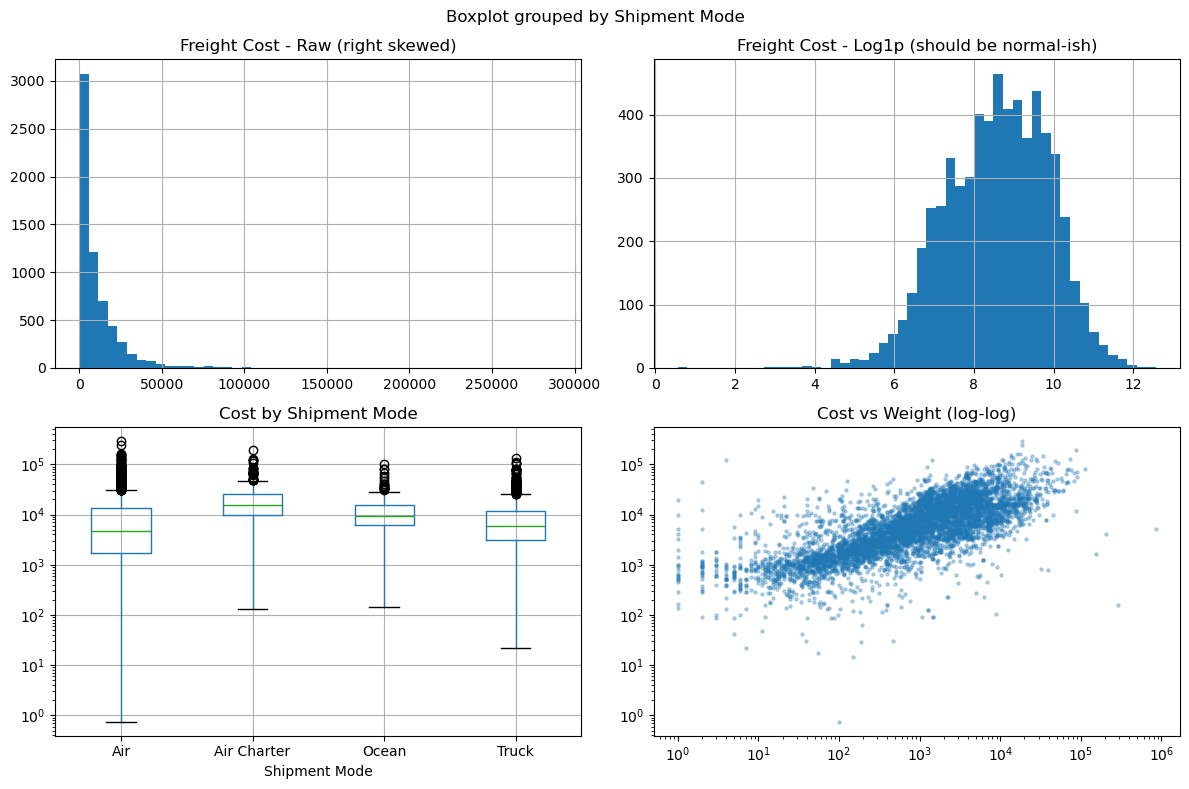

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_clean['Freight Cost (USD)'] = df_clean['Freight Cost (USD)'].astype(float)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Raw freight cost distribution
df_clean['Freight Cost (USD)'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('Freight Cost - Raw (right skewed)')

# 2. Log-transformed
np.log1p(df_clean['Freight Cost (USD)']).hist(bins=50, ax=axes[0,1])
axes[0,1].set_title('Freight Cost - Log1p (should be normal-ish)')

# 3. Cost by mode
df_clean.boxplot(column='Freight Cost (USD)', by='Shipment Mode', ax=axes[1,0])
axes[1,0].set_title('Cost by Shipment Mode')
axes[1,0].set_yscale('log')

# 4. Cost vs Weight
df_clean['Weight (Kilograms)'] = pd.to_numeric(df_clean['Weight (Kilograms)'], errors='coerce')
axes[1,1].scatter(df_clean['Weight (Kilograms)'], df_clean['Freight Cost (USD)'], alpha=0.3, s=5)
axes[1,1].set_xscale('log')
axes[1,1].set_yscale('log')
axes[1,1].set_title('Cost vs Weight (log-log)')

plt.tight_layout()
plt.savefig('figures/eda_plots.png', dpi=150)
plt.show()

In [21]:
print(df_clean['Weight (Kilograms)'].isna().sum())
print(df_clean['Weight (Kilograms)'].describe())

23
count      6175.000000
mean       3430.476437
std       13663.451601
min           0.000000
25%         210.000000
50%        1054.000000
75%        3335.500000
max      857354.000000
Name: Weight (Kilograms), dtype: float64


In [22]:
df_clean[df_clean['Weight (Kilograms)'] > 100000][['Country', 'Shipment Mode', 
    'Weight (Kilograms)', 'Freight Cost (USD)', 'Item Description']].head(10)

,Country,Shipment Mode,Weight (Kilograms),Freight Cost (USD),Item Description
661,Côte d'Ivoire,Air,205503.0,4110.88,"HIV 1/2, Determine Complete HIV Kit, 100 Tests"
779,Côte d'Ivoire,Air,291096.0,156.97,"HIV 1/2, Determine Complete HIV Kit, 100 Tests"
417,Zambia,Air,857354.0,5157.65,"HIV 1/2, Determine Complete HIV Kit, 100 Tests"
4922,Côte d'Ivoire,Air,154780.0,1664.12,"Abacavir/Lamivudine 600/300mg, scored tablets,..."
7441,Mozambique,Truck,112027.0,79514.44,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...


In [23]:
print(df_clean[df_clean['Weight (Kilograms)'] == 0].shape[0])

1


In [26]:
# Is weight = unit weight * quantity?
df_clean['weight_check'] = df_clean['Weight (Kilograms)'] / df_clean['Line Item Quantity']
print(df_clean.loc[[661, 779, 417], ['Weight (Kilograms)', 'Line Item Quantity', 'weight_check', 'Unit of Measure (Per Pack)']])

print(df_clean[df_clean['Weight (Kilograms)'] == 0].shape[0])

print(df_clean['Weight (Kilograms)'].quantile(0.99))
print(df_clean['Weight (Kilograms)'].quantile(0.95))

     Weight (Kilograms)  Line Item Quantity  weight_check  \
661            205503.0                 600    342.505000   
779            291096.0                 850    342.465882   
417            857354.0                2500    342.941600   

     Unit of Measure (Per Pack)  
661                         100  
779                         100  
417                         100  
1
32769.4000000002
12953.699999999979


In [27]:
# Categorical cardinality
for col in ['Country', 'Vendor INCO Term', 'Product Group', 
            'Sub Classification', 'Dosage Form', 'Fulfill Via']:
    print(f"{col}: {df_clean[col].nunique()} unique")

Country: 39 unique
Vendor INCO Term: 8 unique
Product Group: 5 unique
Sub Classification: 6 unique
Dosage Form: 17 unique
Fulfill Via: 2 unique


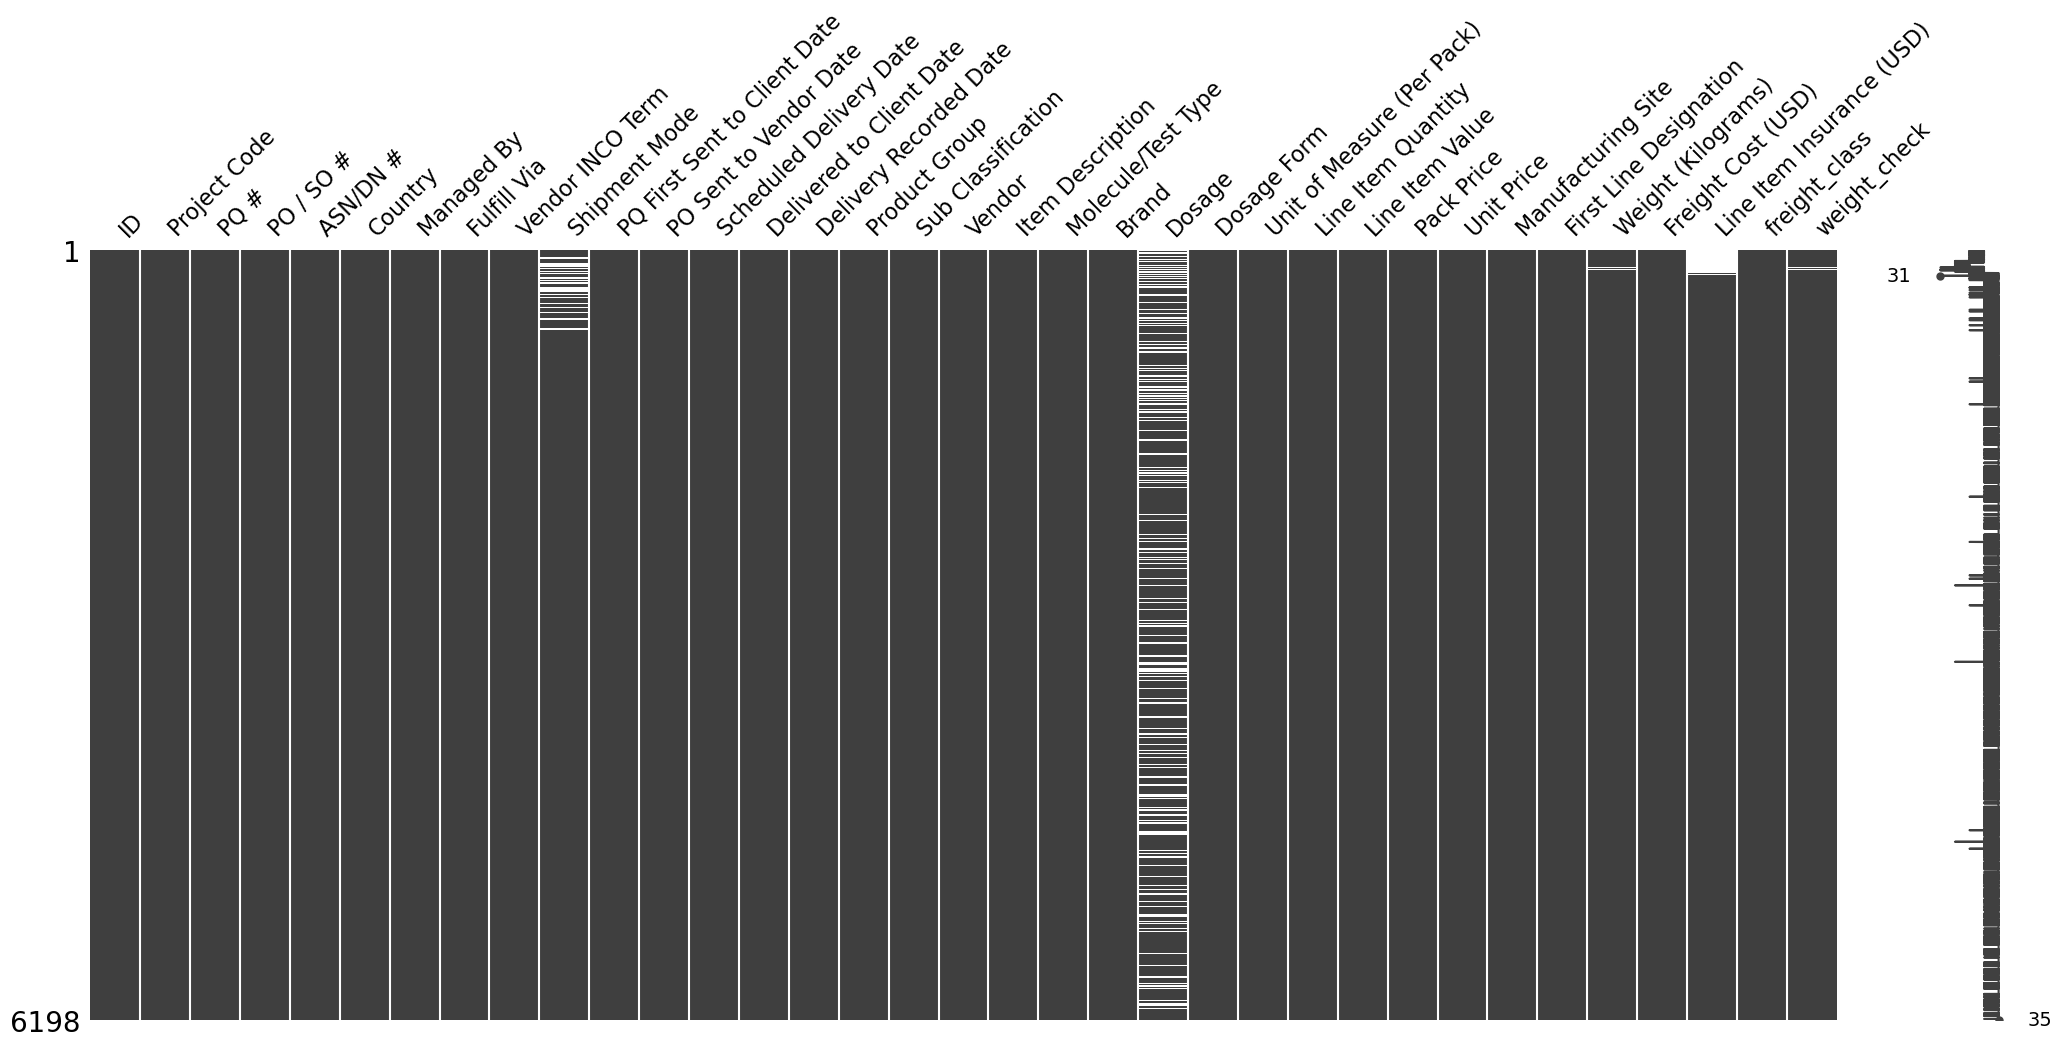

In [29]:
# Missing data heatmap
import missingno as mnx
mnx.matrix(df_clean)
plt.show()

In [ ]:
# 1. Cost by country (top 10)
df_clean.groupby('Country')['Freight Cost (USD)'].agg(['mean','count']).sort_values('mean', ascending=False).head(10)

,mean,count
Country,,
Cameroon,32006.276607,56
Nigeria,18676.113076,764
Sierra Leone,18249.265000,2
Rwanda,16838.552086,350
Kenya,15703.424615,91
Zimbabwe,13536.052853,319
Pakistan,13298.476250,8
Ghana,13162.594762,42
Zambia,12205.874681,517


In [ ]:
# 2. Cost by Product Group
df_clean.groupby('Product Group')['Freight Cost (USD)'].agg(['mean','median','count'])

,mean,median,count
Product Group,,,
ACT,8759.196154,8530.290,13
ANTM,7929.770526,3958.280,19
ARV,10637.512468,5797.030,4790
HRDT,12840.365438,6606.160,1370
MRDT,1388.141667,675.345,6


In [33]:
# 3. Cost by INCO Term
df_clean.groupby('Vendor INCO Term')['Freight Cost (USD)'].agg(['mean','median','count'])

,mean,median,count
Vendor INCO Term,,,
CIF,600.375000,600.375,2
CIP,7181.721840,1315.140,163
DAP,793.333333,989.000,3
DDP,8248.140297,6147.080,303
DDU,672.163333,435.000,3
EXW,13035.833498,7019.070,2167
FCA,5793.390483,2707.280,352
N/A - From RDC,10875.045354,6031.150,3205


In [34]:
# 4. Shipment volume over time (Panini's groupby pattern)
df_clean.groupby(df_clean['Delivered to Client Date'].dt.year)['Freight Cost (USD)'].agg(['mean','count'])

,mean,count
Delivered to Client Date,,
2006,6674.854186,43
2007,6918.408376,425
2008,8691.537721,610
2009,7403.143607,671
2010,9369.344539,760
2011,11167.810552,797
2012,12965.165082,852
2013,13992.584253,823
2014,13164.604136,839


In [ ]:
# 5. Correlation matrix — numeric cols only
df_clean[['Weight (Kilograms)','Line Item Quantity','Line Item Value','Pack Price','Freight Cost (USD)']].corr()

,Weight (Kilograms),Line Item Quantity,Line Item Value,Pack Price,Freight Cost (USD)
Weight (Kilograms),1.000000,0.352776,0.348098,-0.041383,0.232052
Line Item Quantity,0.352776,1.000000,0.817382,-0.164236,0.378289
Line Item Value,0.348098,0.817382,1.000000,-0.027447,0.429676
Pack Price,-0.041383,-0.164236,-0.027447,1.000000,-0.017971
Freight Cost (USD),0.232052,0.378289,0.429676,-0.017971,1.000000


In [ ]:
git init
git remote add origin https://github.com/Samzzh0803/freight-cost-rag.git